In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import rdkit
from rdkit.Chem import AllChem
import py3Dmol
from joblib import Parallel, delayed
from ringer.utils import chem, internal_coords
import matplotlib.pyplot as plt

In [ ]:
def visualize_conformer(mol, title, id=0):
    viewer = py3Dmol.view(width=400, height=400)
    if mol.GetNumConformers() > 0:
        mol_block = rdkit.Chem.MolToMolBlock(mol, confId=id)
        viewer.addModel(mol_block, "mol")
        viewer.setStyle({"stick": {"color": "spectrum"}})
        viewer.zoomTo()
        viewer.setBackgroundColor("white")
        print(f"{title} - Conformer {id}")
        return viewer
    else:
        print(f"{title} has no conformers")
        return None

In [ ]:
with open("sample/reconstructed_mols/F.Mec.q.Y.pickle", "rb") as source:
    s_o_mol = pickle.load(source)
s_o_mol.GetNumConformers()

In [ ]:
with open("sample/reconstructed_mols_no_opt/F.Mec.q.Y.pickle", "rb") as source:
    s_no_o_mol = pickle.load(source)
s_no_o_mol.GetNumConformers()

In [ ]:
def compare_ring_bond_lengths_to_training_means(
    mol,
    conf_id=0,
    means_path="assets/models/conditional/training_mean_distances.json",
):
    with open(means_path, "r") as source:
        mean_distances = json.load(source)

    macrocycle_idxs = chem.get_macrocycle_idxs(mol, n_to_c=True)
    if macrocycle_idxs is None:
        raise ValueError("No macrocycle indices found for molecule")

    bond_idxs = internal_coords.get_macrocycle_bond_idxs(macrocycle_idxs)
    conf = mol.GetConformer(int(conf_id))

    atom_labels = ["N", "Calpha", "CO"]
    rows = []
    for ring_pos, (idx1, idx2) in enumerate(bond_idxs):
        atom_label = atom_labels[ring_pos % 3]
        expected = float(mean_distances[atom_label])
        actual = float(AllChem.GetBondLength(conf, int(idx1), int(idx2)))
        delta = actual - expected
        rows.append(
            {
                "ring_bond_pos": ring_pos,
                "atom_i": int(idx1),
                "atom_j": int(idx2),
                "first_atom_label": atom_label,
                "expected_length": expected,
                "actual_length": actual,
                "delta": delta,
            }
        )

    df = pd.DataFrame(rows)
    df["abs_delta"] = df["delta"].abs()
    df["rel_abs_delta_pct"] = 100.0 * df["abs_delta"] / df["expected_length"]

    likely_broken = df.loc[df["abs_delta"].idxmax()].copy()
    return df, likely_broken, macrocycle_idxs, mean_distances

In [ ]:
demo_mol = s_no_o_mol
means_path = "assets/models/conditional/training_mean_distances.json"

with open(means_path, "r") as source:
    mean_distances_demo = json.load(source)

macrocycle_idxs_raw = chem.get_macrocycle_idxs(demo_mol, n_to_c=False)
macrocycle_idxs_n2c = chem.get_macrocycle_idxs(demo_mol, n_to_c=True)
bond_idxs = internal_coords.get_macrocycle_bond_idxs(macrocycle_idxs_n2c)

print("INPUT 1 (raw ring order, n_to_c=False):")
print(macrocycle_idxs_raw)
print("\nOUTPUT 1 (canonical ring order, n_to_c=True, starts at N):")
print(macrocycle_idxs_n2c)

print("\nINPUT 2: get_macrocycle_bond_idxs(macrocycle_idxs_n2c)")
print("Input length:", len(macrocycle_idxs_n2c))
print("Input list:", macrocycle_idxs_n2c)

print("\nOUTPUT 2: wrapped adjacent bond pairs")
print(bond_idxs)
print("Last bond closes ring:", bond_idxs[-1], "==", (macrocycle_idxs_n2c[-1], macrocycle_idxs_n2c[0]))

atom_labels_cycle = ["N", "Calpha", "CO"]
rows = []
for ring_pos, (idx1, idx2) in enumerate(bond_idxs):
    label = atom_labels_cycle[ring_pos % 3]
    rows.append(
        {
            "ring_bond_pos": ring_pos,
            "atom_i(first)": int(idx1),
            "atom_j(second)": int(idx2),
            "assigned_label_from_first_atom": label,
            "mean_length_from_json": float(mean_distances_demo[label]),
            "actual_length": float(AllChem.GetBondLength(demo_mol.GetConformer(0), int(idx1), int(idx2))),
        }
    )

mapping_df = pd.DataFrame(rows)
print("\nFinal mapping used in compare_ring_bond_lengths_to_training_means:")
display(mapping_df)

In [ ]:
def _compare_ring_bonds_single_conf(conf_id, bond_idxs, positions, expected_per_pos, atom_label_per_pos):
    rows = []
    for ring_pos, (idx1, idx2) in enumerate(bond_idxs):
        expected = expected_per_pos[ring_pos]
        actual = float(np.linalg.norm(positions[idx1] - positions[idx2]))
        delta = actual - expected
        rows.append(
            {
                "conf_id": int(conf_id),
                "ring_bond_pos": ring_pos,
                "atom_i": int(idx1),
                "atom_j": int(idx2),
                "first_atom_label": atom_label_per_pos[ring_pos],
                "expected_length": expected,
                "actual_length": actual,
                "delta": delta,
            }
        )
    return rows


def compare_ring_bond_lengths_all_conformers(
    mol,
    means_path="assets/models/conditional/training_mean_distances.json",
    n_jobs=-1,
):
    with open(means_path, "r") as source:
        mean_distances = json.load(source)

    macrocycle_idxs = chem.get_macrocycle_idxs(mol, n_to_c=True)
    if macrocycle_idxs is None:
        raise ValueError("No macrocycle indices found for molecule")

    bond_idxs = internal_coords.get_macrocycle_bond_idxs(macrocycle_idxs)
    if mol.GetNumConformers() == 0:
        raise ValueError("Molecule has no conformers")

    atom_labels = ["N", "Calpha", "CO"]
    atom_label_per_pos = [atom_labels[i % 3] for i in range(len(bond_idxs))]
    expected_per_pos = [float(mean_distances[lbl]) for lbl in atom_label_per_pos]

    conf_positions = [
        (conf.GetId(), np.asarray(conf.GetPositions())) for conf in mol.GetConformers()
    ]

    results = Parallel(n_jobs=n_jobs)(
        delayed(_compare_ring_bonds_single_conf)(
            conf_id, bond_idxs, positions, expected_per_pos, atom_label_per_pos
        )
        for conf_id, positions in conf_positions
    )

    df = pd.DataFrame([row for conf_rows in results for row in conf_rows])
    df["abs_delta"] = df["delta"].abs()
    df["rel_abs_delta_pct"] = 100.0 * df["abs_delta"] / df["expected_length"]

    worst_per_conf = (
        df.loc[df.groupby("conf_id")["abs_delta"].idxmax()]
        .sort_values("abs_delta", ascending=False)
        .reset_index(drop=True)
    )

    return df, worst_per_conf, macrocycle_idxs, mean_distances

In [ ]:
all_bonds_df, worst_per_conf, macrocycle_idxs, _ = compare_ring_bond_lengths_all_conformers(s_no_o_mol)
worst_per_conf

In [ ]:
all_bonds_df, worst_per_conf, macrocycle_idxs, _ = compare_ring_bond_lengths_all_conformers(s_o_mol)

In [ ]:
worst_per_conf

In [ ]:
target_mol = s_o_mol
target_conf_id = 0

bond_df, likely_broken_row, macrocycle_idxs, training_mean_distances = compare_ring_bond_lengths_to_training_means(
    target_mol,
    conf_id=target_conf_id,
)

print(f"Macrocycle atom count: {len(macrocycle_idxs)}")
print(f"Conformer analyzed: {target_conf_id}")
display(bond_df)

print("Likely broken bond during best_dist init (max |delta|):")
display(pd.DataFrame([likely_broken_row]))


In [ ]:
def visualize_conformer_with_broken_bond(
    mol,
    title,
    conf_id=0,
    broken_bond=None,
    label_text=None,
    width=700,
    height=550,
):
    viewer = py3Dmol.view(width=width, height=height)
    if mol.GetNumConformers() == 0:
        print(f"{title} has no conformers")
        return None

    mol_block = rdkit.Chem.MolToMolBlock(mol, confId=int(conf_id))
    viewer.addModel(mol_block, "mol")
    viewer.setStyle({}, {"stick": {"color": "lightgray", "radius": 0.12}})

    if broken_bond is not None:
        idx1, idx2 = map(int, broken_bond)
        viewer.setStyle(
            {"index": [idx1, idx2]},
            {"stick": {"color": "red", "radius": 0.26}, "sphere": {"color": "red", "radius": 0.36}},
        )

        conf = mol.GetConformer(int(conf_id))
        p1 = conf.GetAtomPosition(idx1)
        p2 = conf.GetAtomPosition(idx2)
        start = {"x": float(p1.x), "y": float(p1.y), "z": float(p1.z)}
        end = {"x": float(p2.x), "y": float(p2.y), "z": float(p2.z)}
        mid = {
            "x": 0.5 * (start["x"] + end["x"]),
            "y": 0.5 * (start["y"] + end["y"]),
            "z": 0.5 * (start["z"] + end["z"]),
        }

        viewer.addLine({"start": start, "end": end, "color": "red", "linewidth": 6})
        viewer.addLabel(
            label_text if label_text is not None else f"Likely broken init bond: {idx1}-{idx2}",
            {
                "position": mid,
                "fontSize": 13,
                "backgroundColor": "black",
                "fontColor": "white",
                "inFront": True,
            },
        )
        viewer.zoomTo({"index": [idx1, idx2]})

    viewer.setBackgroundColor("white")
    print(f"{title} - Conformer {conf_id}")
    return viewer


broken_bond = (int(likely_broken_row["atom_i"]), int(likely_broken_row["atom_j"]))
label = (
    f"Likely broken init bond {broken_bond[0]}-{broken_bond[1]} | "
    f"actual={likely_broken_row['actual_length']:.3f} A, "
    f"expected={likely_broken_row['expected_length']:.3f} A, "
    f"delta={likely_broken_row['delta']:+.3f} A"
)

viewer_broken = visualize_conformer_with_broken_bond(
    target_mol,
    title="s_no_o_mol (likely broken bond highlighted)",
    conf_id=target_conf_id,
    broken_bond=broken_bond,
    label_text=label,
)
if viewer_broken:
    viewer_broken.show()


In [ ]:
viewer2 = visualize_conformer(s_no_o_mol, "s_no_o_mol", id=1475)
if viewer2:
    viewer2.show()

In [ ]:
viewer1 = visualize_conformer(s_o_mol, "s_o_mol", id=1475)
if viewer1:
    viewer1.show()

# Bond length check all molecules

In [2]:
with open("assets/models/conditional/training_mean_distances.json") as f:
    training_means = json.load(f)
overall_training_mean = np.mean(list(training_means.values()))

df_opt = pd.read_csv("sample/ring_bond_length_check.csv")
df_noopt = pd.read_csv("sample/ring_bond_length_check_no_opt.csv")

print(f"Training means: {training_means}")
print(f"Overall avg: {overall_training_mean:.6f}")
print(f"Optimized: {df_opt.shape[0]} rows, {df_opt['molecule'].nunique()} molecules")
print(f"No-opt:    {df_noopt.shape[0]} rows, {df_noopt['molecule'].nunique()} molecules")

Training means: {'N': 1.4554429785247358, 'Calpha': 1.5352094074926335, 'CO': 1.3386375832494648}
Overall avg: 1.443097
Optimized: 1723669 rows, 1000 molecules
No-opt:    1755796 rows, 1000 molecules


## Largest rel_abs_delta_pct per molecule (worst conformer)

In [6]:
def best_conformer_per_molecule(df):
    worst_per_conf_idx = df.groupby(["molecule", "conf_id"])["rel_abs_delta_pct"].idxmax()
    worst_per_conf = df.loc[worst_per_conf_idx]
    best_idx = worst_per_conf.groupby("molecule")["rel_abs_delta_pct"].idxmax()
    best = worst_per_conf.loc[best_idx][
        ["molecule", "conf_id", "rel_abs_delta_pct", "abs_delta", "actual_length", "expected_length", "first_atom_label"]
    ].sort_values("rel_abs_delta_pct")
    return best

In [ ]:
best_opt = best_conformer_per_molecule(df_opt)
best_noopt = best_conformer_per_molecule(df_noopt)

In [9]:
print("=== Optimized — best conformer per molecule (top 5) ===")
display(best_opt.head())
print("\n... worst 10:")
display(best_opt.tail(10))

print("\n=== No-opt — best conformer per molecule (top 5) ===")
display(best_noopt.head())
print("\n... worst 10:")
display(best_noopt.tail(10))

=== Optimized — best conformer per molecule (top 5) ===


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
1054300,S.C.A.N.C,114,0.106025,0.001543,1.4539,1.455443,N
1661042,n.Q.F.f.Q,132,0.106026,0.001543,1.4539,1.455443,N
379922,I.V.C.Y.G,551,0.106026,0.001543,1.4539,1.455443,N
231462,F.w.Mel.T.Q,420,0.106027,0.001543,1.4539,1.455443,N
1393206,W.W.F.G.I,1358,0.106027,0.001543,1.4539,1.455443,N



... worst 10:


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
1622228,i.i.T.G.P,26,12.538758,0.192496,1.342713,1.535209,Calpha
1384052,W.T.MeA.S.I,983,12.609627,0.193584,1.341625,1.535209,Calpha
238710,G.I.P.L.A.T,1159,12.623431,0.168982,1.507620,1.338638,CO
1543932,Y.V.K.T,3339,12.923643,0.198405,1.336804,1.535209,Calpha
185348,F.MeI.L.V.Q,102,13.349926,0.204949,1.330260,1.535209,Calpha
1519967,Y.Q.I.W.A,2457,15.347096,0.205442,1.544080,1.338638,CO
828558,Mew.T.W.MeC,301,16.324437,0.250614,1.284595,1.535209,Calpha
369456,I.S.P.Y.P.W,2699,18.196814,0.279359,1.255850,1.535209,Calpha
570702,MeF.P.MeC.y.Mew.C,3284,19.843950,0.265639,1.604276,1.338638,CO
502538,L.MeY.Met.V,443,51.991813,0.798183,0.737026,1.535209,Calpha



=== No-opt — best conformer per molecule (top 5) ===


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
249622,G.L.G.G,10,0.992655,0.014448,1.469891,1.455443,N
1140908,S.a.F.G,56,1.306839,0.019020,1.474463,1.455443,N
303330,H.G.G.A,8,1.401568,0.020399,1.475842,1.455443,N
16186,A.G.G.A,4,1.630802,0.023735,1.479178,1.455443,N
164094,F.G.G.G,13,1.700706,0.024753,1.480196,1.455443,N



... worst 10:


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
380768,I.S.P.Y.P.W,2239,112.455171,1.636721,3.092164,1.455443,N
592770,MeF.Y.F.MeT.Q.Q,1141,115.644081,1.548055,2.886693,1.338638,CO
733614,Mec.S.Men.w.MeC.n,2445,116.524101,1.695942,3.151385,1.455443,N
980674,P.N.T.w.A.S,1058,120.437517,1.752899,3.208342,1.455443,N
1540638,Y.N.V.Y.L.C,1814,120.690828,1.756586,3.212029,1.455443,N
1108508,S.Meq.W.L.F.I,2535,121.188384,1.763828,3.219271,1.455443,N
73186,C.F.MeI.P.G.S,1664,125.949180,1.833118,3.288561,1.455443,N
1752880,y.p.W.p.i.p,1631,129.946463,1.891297,3.346740,1.455443,N
587374,MeF.P.MeC.y.Mew.C,921,131.890139,1.919586,3.375029,1.455443,N
100014,C.Mel.Y.G.Mei.Mes,1102,132.013994,1.921388,3.376831,1.455443,N


## Avg actual bond length per conformer — distribution

In [10]:
summary_opt = (
    df_opt.groupby(["molecule", "conf_id"])
    .agg(avg_actual_length=("actual_length", "mean"),
         max_abs_delta=("abs_delta", "max"),
         max_rel_abs_delta_pct=("rel_abs_delta_pct", "max"))
    .reset_index()
)
summary_noopt = (
    df_noopt.groupby(["molecule", "conf_id"])
    .agg(avg_actual_length=("actual_length", "mean"),
         max_abs_delta=("abs_delta", "max"),
         max_rel_abs_delta_pct=("rel_abs_delta_pct", "max"))
    .reset_index()
)
summary_opt.to_csv("sample/ring_bond_length_summary.csv", index=False)
summary_noopt.to_csv("sample/ring_bond_length_summary_no_opt.csv", index=False)
print(f"Saved summaries: opt={len(summary_opt)} rows, no_opt={len(summary_noopt)} rows")

Saved summaries: opt=1723669 rows, no_opt=1755796 rows


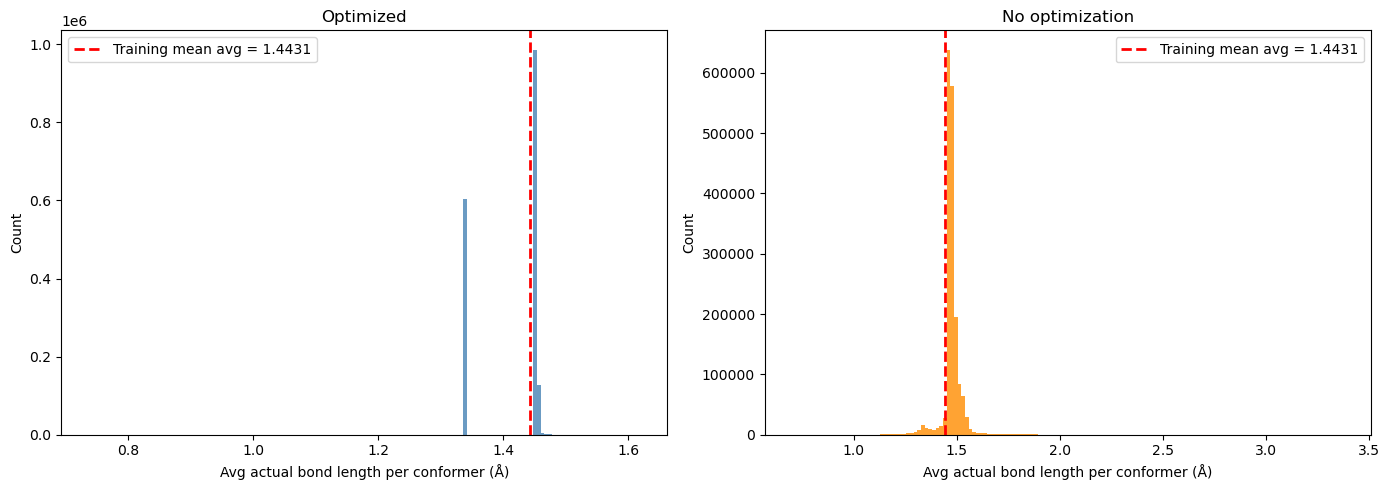

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(summary_opt["avg_actual_length"], bins=150, alpha=0.8, color="steelblue", edgecolor="none")
axes[0].axvline(overall_training_mean, color="red", linewidth=2, linestyle="--",
                label=f"Training mean avg = {overall_training_mean:.4f}")
axes[0].set_title("Optimized")
axes[0].set_xlabel("Avg actual bond length per conformer (Å)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(summary_noopt["avg_actual_length"], bins=150, alpha=0.8, color="darkorange", edgecolor="none")
axes[1].axvline(overall_training_mean, color="red", linewidth=2, linestyle="--",
                label=f"Training mean avg = {overall_training_mean:.4f}")
axes[1].set_title("No optimization")
axes[1].set_xlabel("Avg actual bond length per conformer (Å)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
df_opt[(df_opt["molecule"] == "A.C.C.I") & (df_opt["conf_id"] == 374)]

,molecule,conf_id,ring_bond_pos,atom_i,atom_j,first_atom_label,expected_length,actual_length,delta,abs_delta,rel_abs_delta_pct
0,A.C.C.I,374,6,11,8,N,1.455443,1.45862,0.003177,0.003177,0.218303
